<a href="https://colab.research.google.com/github/RishabKrPandey/Chocolate-Sales-Analysis/blob/main/Chocolate_Sales_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("saidaminsaidaxmadov/chocolate-sales")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'chocolate-sales' dataset.
Path to dataset files: /kaggle/input/chocolate-sales


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

In [ ]:
import os

# List the contents of the directory
print(os.listdir(path))

# Assuming the CSV file is named 'chocolate_sales.csv' or similar within the directory
# You might need to adjust the filename based on the output of os.listdir(path)
# For demonstration, let's assume there's a file called 'chocolate_sales.csv'

df = pd.read_csv(os.path.join(path, 'Chocolate Sales (2).csv'))
df.head()

['ChocolateSales.pbix', 'Chocolate Sales (2).csv', 'ChocolateSales.pdf', 'ChocolateSales.pbit']


,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,04/01/2022,"$5,320.00",180
1,Van Tuxwell,India,85% Dark Bars,01/08/2022,"$7,896.00",94
2,Gigi Bohling,India,Peanut Butter Cubes,07/07/2022,"$4,501.00",91
3,Jan Morforth,Australia,Peanut Butter Cubes,27/04/2022,"$12,726.00",342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,24/02/2022,"$13,685.00",184


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3282 entries, 0 to 3281
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Sales Person   3282 non-null   object        
 1   Country        3282 non-null   object        
 2   Product        3282 non-null   object        
 3   Date           3282 non-null   datetime64[ns]
 4   Amount         3282 non-null   float64       
 5   Boxes Shipped  3282 non-null   int64         
dtypes: datetime64[ns](1), float64(1), int64(1), object(3)
memory usage: 154.0+ KB


In [ ]:
df.head()

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,04/01/2022,"$5,320.00",180
1,Van Tuxwell,India,85% Dark Bars,01/08/2022,"$7,896.00",94
2,Gigi Bohling,India,Peanut Butter Cubes,07/07/2022,"$4,501.00",91
3,Jan Morforth,Australia,Peanut Butter Cubes,27/04/2022,"$12,726.00",342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,24/02/2022,"$13,685.00",184


In [ ]:
df['Amount'] = df['Amount'].str.replace('$', '').str.replace(',', '')
df['Amount'] = pd.to_numeric(df['Amount'])

In [ ]:
df.describe()

,Amount,Boxes Shipped
count,3282.000000,3282.000000
mean,6030.338775,164.666971
std,4393.980200,124.024736
min,7.000000,1.000000
25%,2521.495000,71.000000
50%,5225.500000,137.000000
75%,8556.842500,232.000000
max,26170.950000,778.000000


In [ ]:
df['Date'] = df['Date'].astype('datetime64[ns]')

In [ ]:
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

In [ ]:
#Price Per Box
df['Price Per Box'] = df['Amount'] / df['Boxes Shipped']

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3282 entries, 0 to 3281
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Sales Person   3282 non-null   object        
 1   Country        3282 non-null   object        
 2   Product        3282 non-null   object        
 3   Date           3282 non-null   datetime64[ns]
 4   Amount         3282 non-null   float64       
 5   Boxes Shipped  3282 non-null   int64         
 6   Month          3282 non-null   int32         
 7   Year           3282 non-null   int32         
 8   Price Per Box  3282 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int32(2), int64(1), object(3)
memory usage: 205.3+ KB


## Which product are the 'Cash Cows'?

In [ ]:
# Group by Product to see total revenue and total boxes sold
product_performance = df.groupby('Product').agg({
    'Amount' : 'sum',
    'Boxes Shipped' : 'sum',
    'Price Per Box' : 'mean'
}).sort_values(by='Amount', ascending=False)

product_performance.head(5)

,Amount,Boxes Shipped,Price Per Box
Product,,,
Smooth Sliky Salty,1120201.09,26969,92.188668
50% Dark Bites,1087659.35,29810,117.096311
White Choc,1054257.00,25158,246.487640
Peanut Butter Cubes,1036591.09,25339,96.841860
Eclairs,996947.96,26678,124.347012


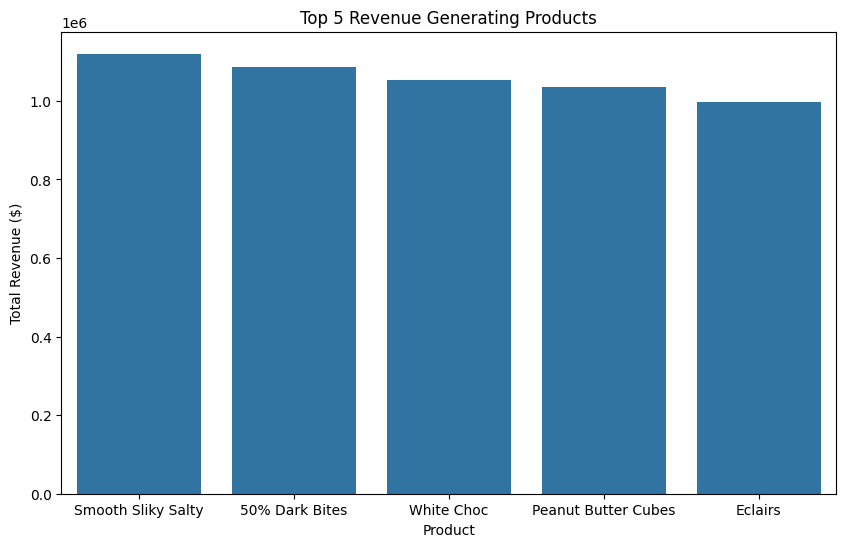

In [ ]:
# Visualization
plt.figure(figsize = (10, 6))
sns.barplot(x = product_performance.head(5).index, y = product_performance.head(5)['Amount'])
plt.title("Top 5 Revenue Generating Products")
plt.ylabel("Total Revenue ($)")
plt.show()

## Who are the top Salespeople?

In [ ]:
sales_team = df.groupby('Sales Person').agg({
    'Amount'  : 'sum',
    'Boxes Shipped' : 'sum',
    'Price Per Box' : 'mean'
}).sort_values(by='Amount', ascending=False)

sales_team.head()

,Amount,Boxes Shipped,Price Per Box
Sales Person,,,
Ches Bonnell,1022599.96,23070,110.753666
Oby Sorrel,1017204.12,26390,93.157882
Madelene Upcott,1010028.72,22199,159.104593
Kelci Walkden,1002929.10,26605,91.381636
Brien Boise,997326.48,24738,78.843201


## Regional Performance

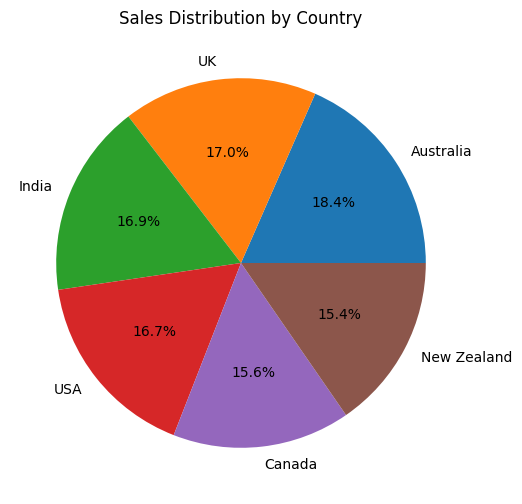

In [ ]:
geo_sales = df.groupby('Country')['Amount'].sum().sort_values(ascending= False)

plt.figure(figsize = (10, 6))
geo_sales.plot(kind = 'pie', autopct = '%1.1f%%')
plt.title("Sales Distribution by Country")
plt.ylabel("")
plt.show()

## Seasonality

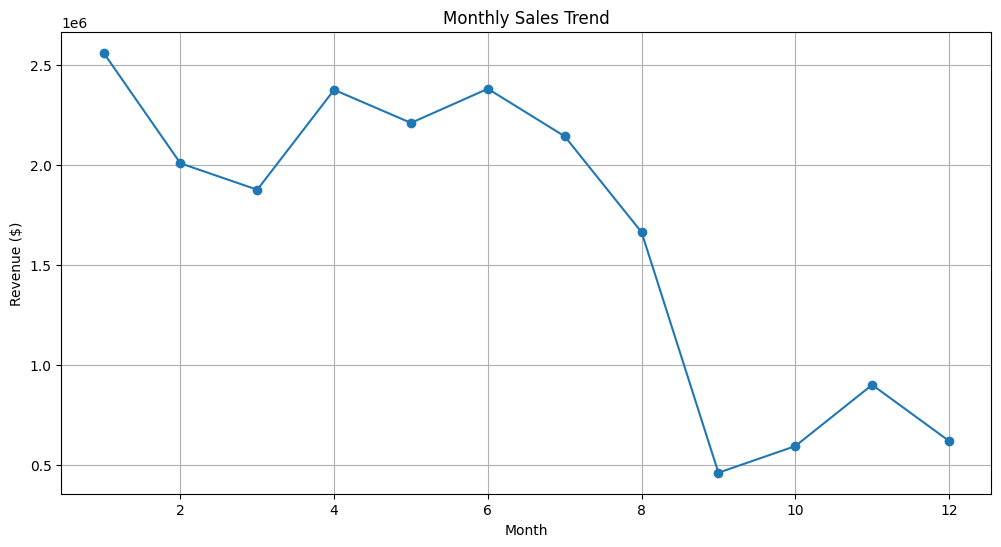

In [ ]:
monthly_sales = df.groupby('Month')['Amount'].sum()

plt.figure(figsize=(12, 6))
monthly_sales.plot(kind = 'line', marker = 'o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Revenue ($)')
plt.grid(True)
plt.show()

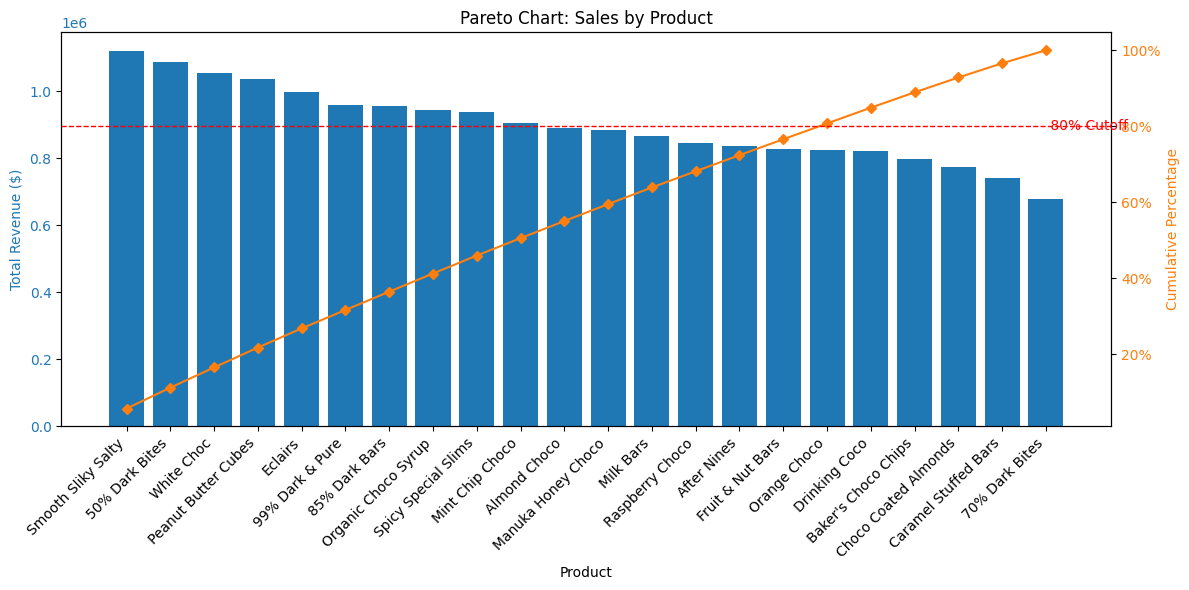

Top Contributors (The 'Vital Few' accounting for ~80% of sales):
                         Amount  Cumulative Percentage
Product                                               
Smooth Sliky Salty   1120201.09               5.659991
50% Dark Bites       1087659.35              11.155559
White Choc           1054257.00              16.482357
Peanut Butter Cubes  1036591.09              21.719895
Eclairs               996947.96              26.757129
99% Dark & Pure       960033.45              31.607848
85% Dark Bars         955268.24              36.434490
Organic Choco Syrup   945345.73              41.210996
Spicy Special Slims   938131.69              45.951053
Mint Chip Choco       904989.55              50.523653
Almond Choco          890454.65              55.022814
Manuka Honey Choco    885208.03              59.495466
Milk Bars             866273.62              63.872448
Raspberry Choco       845388.41              68.143905
After Nines           837215.67              72.374067


In [ ]:
# Group by the category you want to analyze (e.g., 'Product', 'Sales Person', 'Country')
category = 'Product'
pareto_df = df.groupby(category).agg({'Amount': 'sum'}).sort_values(by='Amount', ascending=False)

# Calculate cumulative percentage
pareto_df['Cumulative Percentage'] = pareto_df['Amount'].cumsum() / pareto_df['Amount'].sum() * 100

# --- PLOTTING STEP ---
fig, ax1 = plt.subplots(figsize=(12, 6))

# Bar Chart (Left Axis): Total Sales per Product
ax1.bar(pareto_df.index, pareto_df['Amount'], color='C0')
ax1.set_ylabel('Total Revenue ($)', color='C0')
ax1.tick_params(axis='y', labelcolor='C0')
ax1.set_xlabel(category)
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability

# Line Chart (Right Axis): Cumulative Percentage
ax2 = ax1.twinx()
ax2.plot(pareto_df.index, pareto_df['Cumulative Percentage'], color='C1', marker='D', ms=5)
ax2.set_ylabel('Cumulative Percentage', color='C1')
ax2.tick_params(axis='y', labelcolor='C1')
ax2.yaxis.set_major_formatter(PercentFormatter())

# Add a reference line at 80%
ax2.axhline(80, color='red', linestyle='--', linewidth=1)
ax2.text(len(pareto_df)-1, 80, ' 80% Cutoff', color='red', va='center')

plt.title(f'Pareto Chart: Sales by {category}')
plt.tight_layout()
plt.show()

# --- OUTPUT THE "VITAL FEW" ---
print("Top Contributors (The 'Vital Few' accounting for ~80% of sales):")
print(pareto_df[pareto_df['Cumulative Percentage'] <= 80])